## **MSP baseline (Max Softmax Probability)**

1. Uniform distribution as a softmax prediction is very very unlikely due to the nature of the function itself. Softmax gives highly confident probability scores to even out of distribution examples but still smaller than what it would give to some example from the distribution

2. One way of looking at AUROC is Probability(Score of positive > Score of negative) : Treats both classes symmetrically but this is misleading when imbalanced classes. P(S>E) = P(-E>-S) - Can be overly optimistic in case of one class being rare

3. AUPR depends strongly on which class we label as positive and how common is that class -  Good for imbalanced classes Precision = (TP/TP+FP) suppose Positives are very rare then TP will be very less and so every FP will be highly costly for AUPR - we report 2 AUPRs treating different classes as positive in both curves - AUPR with rare as positive matters more 

4. AUROC vs AUPR : AUROC is NOT ideal when positive and negative classes have highly different base rates (imbalanced) - Say positives are very rare : Model can make many False positive predictions and still have low False Positive Rate and increase AUROC (In case where almost all are negative, model predicting many more positives than actual will not be punished well enough by AUROC - Precision fixes exactly that )

5. So a trained model is run on all test examples and for each test example, the highest probability class’s probability is extracted and now attach with them their in/out of distribution label and find AUROC/AUPR

6. Abnormality Module and Auxiliary Decoder : We first train only blue layers on in distribution data, then freeze them and train red layers on in-distribution as well as synthetic noise and out of distribution examples. Hope/Drawback is that general out of distribution will be learnt to be out of distribution by the noise we feed

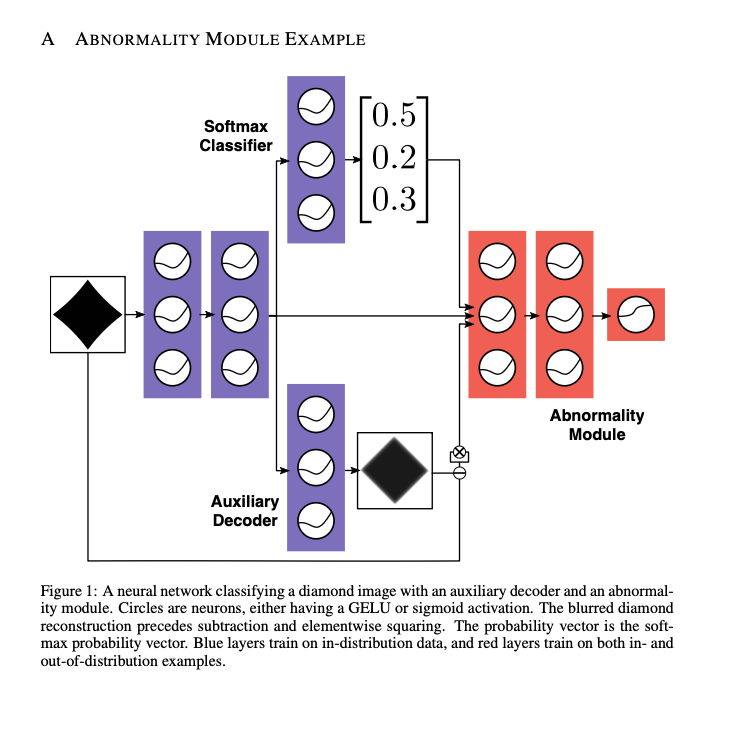

**Imports and Utility**

In [28]:
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader,TensorDataset
from torchvision import datasets,transforms
from sklearn.metrics import roc_auc_score,average_precision_score,precision_recall_curve

device = "mps"
torch.manual_seed(0)

In [20]:
def load_mnist():
    trfm = transforms.Compose([
        (transforms.ToTensor())
    ])
    train = datasets.MNIST(root='./data',train=True,download=True,transform=trfm)
    test = datasets.MNIST(root='./data',train=False,download=True,transform=trfm)
    return train,test

def flatten_dataset(ds):
    loader = DataLoader(ds,batch_size=len(ds))
    for X,y in loader:
        return X.flatten(1),y

**Model Architectures**

In [21]:
class ClassifierWithDecoder(nn.Module):
    def __init__(self,input_dim=784,hidden=256,n_classes=10):
        super().__init__()
        
        self.common = nn.Sequential(
            nn.Linear(input_dim,hidden),
            nn.GELU(),
            nn.Linear(hidden,hidden),
            nn.GELU()
        )
        
        self.classifier = nn.Linear(hidden,n_classes)
        
        self.decoder = nn.Sequential(
            nn.Linear(hidden,hidden),
            nn.GELU(),
            nn.Linear(hidden,input_dim),
            nn.GELU(),
            nn.Sigmoid() # Squish to [0,1] to compare with processed version of input
        )
    
    def forward(self,x):
        feats = self.common(x)
        
        logits = self.classifier(feats)
        probs = F.softmax(logits,dim=1)
        
        reconstr = self.decoder(feats)
        return logits,probs,reconstr,feats

In [ ]:
class AbnormalityModule(nn.Module):
    def __init__(self,feat_dim=256,input_dim=784,n_classes=10,hidden=256):
        super().__init__()
        
        self.net = nn.Sequential(
            nn.Linear(feat_dim+input_dim+n_classes,hidden), # Combined all 3 because the paper's figure showed so
            nn.GELU(),
            nn.Linear(hidden,hidden),
            nn.GELU(),
            nn.Linear(hidden,1)
        )
        
    def forward(self,feats,probs,sq_error):
        z = torch.cat([feats,probs,sq_error],dim=1)
        return torch.sigmoid(self.net(z)).squeeze(1)

**Noise Addition Functions**

In [ ]:
# Functions for Batch of data -> Batch of noisy data 

def add_gaussian_noise(x,std=0.5):
    return torch.clamp(x+std*torch.randn_like(x),0,1)

def add_uniform_noise(x,noise_level=0.1):
    noise = (torch.rand_like(x)*2-1) * noise_level
    return torch.clamp(x+noise,0,1)

def blur_batch(x_flat,kernel_size=3):
    x = x_flat.view(-1,1,28,28)
    pad = kernel_size//2
    x = F.avg_pool2d(F.pad(x,[pad]*4,mode="replicate"),kernel_size=kernel_size,stride=1)
    return x.view(x.shape[0],-1)

def rotate_batch(x_flat,degrees=45):
    import torchvision.transforms.functional as tf
    x = x_flat.view(-1,1,28,28)
    out = torch.empty_like(x)
    for i in range(x.shape[0]):
        angle = float(np.random.uniform(-degrees,degrees))
        out[i]=tf.rotate(x[i],angle)
    return out.view(out.shape[0],-1)

def make_abnormal_batch(x_flat):
    choice = np.random.randint(4)
    if choice == 0:
        return add_gaussian_noise(x_flat)
    if choice == 1:
        return add_uniform_noise(x_flat)
    if choice == 2:
        return blur_batch(x_flat)
    else:
        return rotate_batch(x_flat)

In [ ]:
def train_classifier_decoder(model,X_train,y_train,epochs=15,batch_size=128,lr=1e-3):
    model.to(device)
    model.train()
    
    optimizer = torch.optim.Adam(model.parameters(),lr=lr)
    ds = TensorDataset(X_train,y_train)
    loader = DataLoader(ds,batch_size=batch_size,shuffle=True)
    
    for epoch in range(epochs):
        total_ce,total_recon,n = 0,0,0
        
        for X,y in loader:
            X = X.to(device)
            y = y.to(device)
            optimizer.zero_grad()
            logits,probs,reconstr,feats = model(X)
            ce_loss = F.cross_entropy(logits,y)
            recon_loss = F.mse_loss(reconstr,X)
            loss = ce_loss+recon_loss
            loss.backward()
            optimizer.step()
            
            total_ce+=ce_loss.item()*X.shape[0]
            total_recon+=recon_loss.item()*X.shape[0]
            n+=X.shape[0]
            
        print(f"[classifier+decoder] epoch {epoch + 1}/{epochs} ce={total_ce / n:.4f} recon={total_recon / n:.4f}")
    return model

In [25]:
def train_abnormality_module(clf_decoder,ab_module,X_train,y_train,epochs=2,batch_size=128,lr=1e-3):
    clf_decoder.eval()
    for param in clf_decoder.parameters():
        param.requires_grad = False
    
    ab_module.to(device)
    ab_module.train()
    
    optimizer = torch.optim.Adam(ab_module.parameters(),lr=lr)
    ds = TensorDataset(X_train)
    loader = DataLoader(ds,batch_size=batch_size,shuffle=True)
    
    for epoch in range(epochs):
        total_loss,n = 0,0
        
        for (X,) in loader:
            X = X.to(device)
            X_abnormal = make_abnormal_batch(X.cpu().to(device))
            
            X_modified = torch.cat([X,X_abnormal],dim=0)
            labels = torch.cat([torch.zeros(X.shape[0]),torch.ones(X_abnormal.shape[0])]).to(device) # Clean:0 Noise:1
            
            with torch.no_grad():
                logits,probs,reconstr,feats = clf_decoder(X_modified)
                sq_error = (reconstr - X_modified)**2
                
            optimizer.zero_grad()
            scores = ab_module(feats,probs,sq_error)
            loss = F.binary_cross_entropy(scores,labels)
            loss.backward()
            optimizer.step()
            
            total_loss+=loss.item()*X_modified.shape[0]
            n+=X_modified.shape[0]
        print(f"[abnormality module] epoch {epoch + 1}/{epochs} bce={total_loss / n:.4f}")
    return ab_module

In [26]:
@torch.no_grad()
def msp_scores(model,X):
    # Maximum Softmax Probability
    model.eval()
    logits,probs,reconstr,feats = model(X.to(device))
    return probs.max(dim=1).values.cpu().numpy()

@torch.no_grad()
def abnormality_scores(clf_decoder,ab_module,X):
    # Abnormality Module Score
    clf_decoder.eval()
    ab_module.eval()
    X = X.to(device)
    logits,probs,reconstr,feats = clf_decoder(X)
    sq_error = (reconstr-X)**2
    return ab_module(feats,probs,sq_error).cpu().numpy()

def evaluate_ood(in_scores,out_scores,higher_is_in_dist=True):
    if not higher_is_in_dist:
        in_scores,out_scores = -in_scores,-out_scores
 
    labels = np.concatenate([np.ones_like(in_scores),np.zeros_like(out_scores)])
    scores = np.concatenate([in_scores,out_scores])
 
    auroc = roc_auc_score(labels,scores)
    aupr_in = average_precision_score(labels,scores)
    aupr_out = average_precision_score(1-labels,-scores)
    return {"AUROC": auroc, "AUPR_In": aupr_in, "AUPR_Out": aupr_out}

In [27]:
def main():
    train_ds,test_ds = load_mnist()
    train_x,train_y = flatten_dataset(train_ds)
    test_x,test_y = flatten_dataset(test_ds)
 
    model = ClassifierWithDecoder()
    model = train_classifier_decoder(model,train_x,train_y,epochs=15)
 
    test_acc = (model(test_x.to(device))[0].argmax(1).cpu()==test_y).float().mean().item()
    print(f"\nTest accuracy: {test_acc * 100:.2f}%\n")
 
    ood_gaussian = add_gaussian_noise(test_x)
    ood_uniform = add_uniform_noise(test_x)
    ood_blur = blur_batch(test_x)
    ood_rotate = rotate_batch(test_x[:2000])
 
    print("--- MSP baseline ---")
    in_scores = msp_scores(model,test_x)
    for name,ood_x in [("Gaussian",ood_gaussian),("Uniform",ood_uniform),("Blur",ood_blur),("Rotate",ood_rotate)]:
        out_scores = msp_scores(model,ood_x)
        metrics = evaluate_ood(in_scores,out_scores,higher_is_in_dist=True)
        print(f"MNIST/{name}: {metrics}")
 
    ab_module = AbnormalityModule()
    clf_decoder = copy.deepcopy(model)
    ab_module = train_abnormality_module(clf_decoder,ab_module,train_x,train_y,epochs=5)
 
    print("\n--- Abnormality module ---")
    in_scores_ab = abnormality_scores(clf_decoder,ab_module,test_x)
    for name,ood_x in [("Gaussian",ood_gaussian),("Uniform",ood_uniform),("Blur",ood_blur),("Rotate",ood_rotate)]:
        out_scores_ab = abnormality_scores(clf_decoder,ab_module,ood_x)
        metrics = evaluate_ood(in_scores_ab,out_scores_ab,higher_is_in_dist=False)
        print(f"MNIST/{name}: {metrics}")
 
 
if __name__ == "__main__":
    main()

[classifier+decoder] epoch 1/15 ce=0.3317 recon=0.1963
[classifier+decoder] epoch 2/15 ce=0.1248 recon=0.1921
[classifier+decoder] epoch 3/15 ce=0.0830 recon=0.1908
[classifier+decoder] epoch 4/15 ce=0.0591 recon=0.1898
[classifier+decoder] epoch 5/15 ce=0.0446 recon=0.1893
[classifier+decoder] epoch 6/15 ce=0.0341 recon=0.1889
[classifier+decoder] epoch 7/15 ce=0.0251 recon=0.1885
[classifier+decoder] epoch 8/15 ce=0.0197 recon=0.1883
[classifier+decoder] epoch 9/15 ce=0.0150 recon=0.1881
[classifier+decoder] epoch 10/15 ce=0.0180 recon=0.1881
[classifier+decoder] epoch 11/15 ce=0.0124 recon=0.1879
[classifier+decoder] epoch 12/15 ce=0.0126 recon=0.1878
[classifier+decoder] epoch 13/15 ce=0.0069 recon=0.1875
[classifier+decoder] epoch 14/15 ce=0.0110 recon=0.1876
[classifier+decoder] epoch 15/15 ce=0.0102 recon=0.1875

Test accuracy: 97.80%

--- MSP baseline ---
MNIST/Gaussian: {'AUROC': 0.9415392, 'AUPR_In': 0.9453841497206908, 'AUPR_Out': 0.9292491359648948}
MNIST/Uniform: {'AUROC':

# SUMMARY / TAKEAWAYs

**Accuracy**
The trained model scores 97.8% accuracy which is great for a linear network

**MSP Baseline**
Only placing thresholds on maximum probability class's probability and trying to classify yields good results on Gaussian data but fails very badly on Uniform and Blur images

**Abnormality Module**
The softmax gives abnormally confident probabilities even for classes that are OOD, so the abnormality module also "checks" if the model can redraw the input image from the output - in case of a high reconstruction error, the model flags it as OOD